In [1]:
#Preamble
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import os
from scipy.optimize import curve_fit
from sklearn.metrics import root_mean_squared_error, r2_score

# Get NIST data

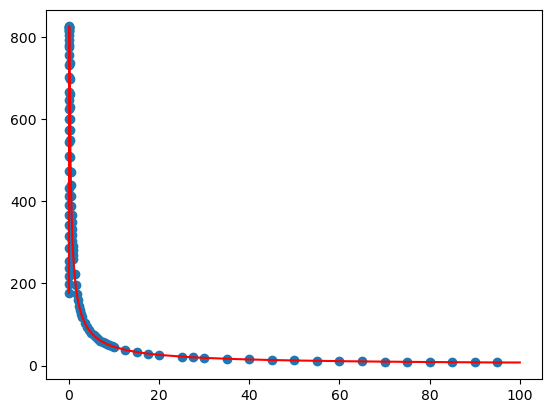

In [2]:
#Load in NIST SP data for protons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata['CSDA'] = data.iloc[:,2]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])
Expanded_SP['CSDA'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['CSDA'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP['Energy'], Expanded_SP['SP'], label='Interpolation', color='r')

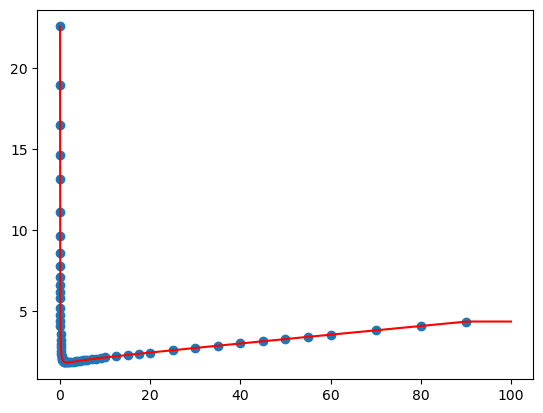

In [3]:
#Load in NIST SP data for electrons
data = pd.read_csv(r"..\TOPAS_data\NIST stopping power electrons.csv", sep='|',header=None)

SPdata = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
SPdata['Energy'] = data.iloc[:,0]
SPdata['SP'] = data.iloc[:,1]
SPdata = SPdata[SPdata['Energy']<100]

#interpolate data down to 4 digits
Expanded_SP_el = pd.DataFrame(columns=['Energy', 'SP', 'CSDA'])
Expanded_SP_el['Energy'] = np.arange(0, 100, 0.0001)
Expanded_SP_el['SP'] = np.interp(Expanded_SP['Energy'], SPdata['Energy'], SPdata['SP'])

plt.scatter(SPdata['Energy'], SPdata['SP'], label='NIST data')
plt.plot(Expanded_SP_el['Energy'], Expanded_SP_el['SP'], label='Interpolation', color='r')

# LET and dose statistics

In [4]:
def Calculate_LET_from_phsp(phsp_path, NIST_data, NIST_data_el):
    try:
        #Read in phsp file
        d = pd.read_csv(phsp_path, header=None, sep='\s+')

        #Select protons
        d_p = d.loc[d.iloc[:,7]==2212]
        d_p.reset_index(inplace=True)

        proton_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        proton_data['Energy'] = d_p.iloc[:,6]
        proton_data['Weight'] = d_p.iloc[:,7]

        #Look up stopping power for each kinetic energy
        for i in range(len(proton_data)):
            en = proton_data.loc[i, 'Energy']

            sp = NIST_data[round(NIST_data['Energy'],4)==round(en,4)]
            
            #convert to LET
            proton_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]


        #Select electrons
        d_e = d.loc[d.iloc[:,7]==11]
        d_e.reset_index(inplace=True)

        el_data = pd.DataFrame(columns=['Energy', 'Weight', 'LET'])
        el_data['Energy'] = d_e.iloc[:,6]
        el_data['Weight'] = d_e.iloc[:,7]
        

        #Look up stopping power for each kinetic energy
        for i in range(len(el_data)):
            en = float(el_data.loc[i, 'Energy'])

            sp = NIST_data_el[round(NIST_data_el['Energy'],4)==round(en,4)]
            
            #convert to LET
            el_data.loc[i, 'LET'] = np.array(sp['SP']/10)[0]
        
        particle_data = pd.concat([proton_data, el_data])

        particle_data['Dose_weights'] = particle_data['Weight']*particle_data['LET']
        particle_data['Dose_weights'] = particle_data['Dose_weights']/particle_data['Dose_weights'].sum()
        particle_data['LET_d'] = particle_data['Dose_weights']*particle_data['LET']

        LET = round(particle_data['LET_d'].sum(),2)
        
        
    except pd.errors.EmptyDataError:
        print('No histories for ' + phsp_path)

        LET = 0

    #print(phsp_path + ' finished')

    return LET

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3984868068.py:4: SyntaxWarning: invalid escape sequence '\s'
  d = pd.read_csv(phsp_path, header=None, sep='\s+')


In [5]:
# print('---low LET---')

# let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer_LET.csv", skiprows=4)
# let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
# print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

# let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
# print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

# dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_LOW\Setup_low_CellLayer_Dose.csv", skiprows=4)
# print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

# print('---mid LET---')

# let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer_LET.csv", skiprows=4)
# let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
# print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

# let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
# print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

# dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_MID\Setup_high_CellLayer_Dose.csv", skiprows=4)
# print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

# print('---high LET---')

# let_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer_LET.csv", skiprows=4)
# let_cells = let_cells['# ProtonLET ( MeV/mm/(g/cm3) ) : Sum   '][0]/10
# print('LET (scorer): ' + str(round(let_cells,2)) + ' keV/um')

# let_phsp = Calculate_LET_from_phsp(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer.phsp", Expanded_SP, Expanded_SP_el)
# print('LET (phsp): ' + str(round(let_phsp,2)) + ' keV/um')

# dose_cells = pd.read_csv(r"..\TOPAS_data\OUTPUTS_PHYSICS_HIGH\Setup_high_CellLayer_Dose.csv", skiprows=4)
# print('Dose: ' + str(dose_cells['# DoseToWater ( Gy ) : Sum   '][0]) + ' Gy')

# Analysis of lineal energy spectra

In [6]:
def read_in_spectrum(masterfolder):
    batches = [name for name in os.listdir(masterfolder)]
    count = 0
    ydata = pd.DataFrame(columns=['y', 'fy', 'yfy', 'dy', 'ydy'])
    i=0

    for batch in batches:
        path = os.path.join(masterfolder, batch, 'ySpecfile.txt')

        #update particle count
        phsp_path = os.path.join(masterfolder, batch, 'MONASScorer.phsp')
        
        try:
            count = count + len(pd.read_csv(phsp_path, header=None, sep='\s+'))
        except:
            continue

        #read in yspec file
        try:
            y = pd.read_csv(path, skiprows=1, header=None, sep='\s+')
            
            if i==0:
                ydata['y'] = y.iloc[:,0]
                ydata['fy'] = y.iloc[:,1]
                ydata['yfy'] = y.iloc[:,3]
                ydata['dy'] = y.iloc[:,5]
                ydata['ydy'] = y.iloc[:,7]
            
            else:
                ydata['fy'] = ydata['fy'].to_numpy() + y.iloc[:,1].to_numpy()
                ydata['yfy'] = ydata['yfy'] + y.iloc[:,3]
                ydata['dy'] = ydata['dy'] + y.iloc[:,5]
                ydata['ydy'] = ydata['ydy'] + y.iloc[:,7]
            
            i += 1

        except FileNotFoundError:
            continue

    print(masterfolder)
    print(str(i) + ' out of ' + str(len(batches)) + ' batches had particle data')
    print('Number of particles: ' + str(count))

    return ydata, count

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\155998024.py:14: SyntaxWarning: invalid escape sequence '\s'
  count = count + len(pd.read_csv(phsp_path, header=None, sep='\s+'))
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\155998024.py:20: SyntaxWarning: invalid escape sequence '\s'
  y = pd.read_csv(path, skiprows=1, header=None, sep='\s+')


In [7]:
def Y_to_LET(spectrumfile):

    y = spectrumfile['y']
    d = spectrumfile['dy']
    weights = d / np.sum(d)

    # LET
    LET = np.sum(y * weights)

    print('Mean: ' + str(round(LET,2)) + ' keV/um')

    #Find standard dev
    STD = np.sqrt(np.sum(weights * np.square(y - LET)))

    print('Standard Dev: ' + str(round(STD, 2)))

    return LET, STD

In [8]:
# Reading in low, only 1 batch
ylow, count = read_in_spectrum(r"..\TOPAS_data\OUTPUTS_MONAS_LOW")

# Reading in mid, several batches
total = 0
ymidtup = {}
counts = []
for i in range(1, 11, 1):
    folder = r"..\TOPAS_data\OUTPUTS_MONAS_MID" + str(i)
    ymidtup[i-1], count = read_in_spectrum(folder)
    counts.append(count)
    total += count

print('Total particles: ' + str(total))

ymid = pd.DataFrame(columns=['y', 'dy'])
ymid['dy'] = np.zeros(len(ymidtup[0]))
for i in range(len(counts)):
    y = ymidtup[i]

    if i == 0:
        ymid['y'] = y['y']
        
    ymid['dy'] += (counts[i]/total)*y['dy']

# Reading in high, several batches
total = 0
yhightup = {}
counts = []
for i in range(1, 13, 1):
    folder = r"..\TOPAS_data\OUTPUTS_MONAS_HIGH" + str(i)
    yhightup[i-1], count = read_in_spectrum(folder)
    counts.append(count)
    total += count

print('Total particles: ' + str(total))

yhigh = pd.DataFrame(columns=['y', 'dy'])
yhigh['dy'] = np.zeros(len(yhightup[0]))
for i in range(len(counts)):
    y = yhightup[i]
    Y_to_LET(y)

    if i == 0:
        yhigh['y'] = y['y']
        
    yhigh['dy'] += (counts[i]/total)*y['dy']


..\TOPAS_data\OUTPUTS_MONAS_LOW
7 out of 10 batches had particle data
Number of particles: 2038
..\TOPAS_data\OUTPUTS_MONAS_MID1
8 out of 10 batches had particle data
Number of particles: 127
..\TOPAS_data\OUTPUTS_MONAS_MID2
10 out of 10 batches had particle data
Number of particles: 154
..\TOPAS_data\OUTPUTS_MONAS_MID3
10 out of 10 batches had particle data
Number of particles: 168
..\TOPAS_data\OUTPUTS_MONAS_MID4
10 out of 10 batches had particle data
Number of particles: 192
..\TOPAS_data\OUTPUTS_MONAS_MID5
10 out of 10 batches had particle data
Number of particles: 169
..\TOPAS_data\OUTPUTS_MONAS_MID6
10 out of 10 batches had particle data
Number of particles: 161
..\TOPAS_data\OUTPUTS_MONAS_MID7
10 out of 10 batches had particle data
Number of particles: 167
..\TOPAS_data\OUTPUTS_MONAS_MID8
10 out of 10 batches had particle data
Number of particles: 182
..\TOPAS_data\OUTPUTS_MONAS_MID9
9 out of 10 batches had particle data
Number of particles: 144
..\TOPAS_data\OUTPUTS_MONAS_MID10

In [9]:
def generate_binwidths(input):
    # input = df column 'y' from the spectrum
    try:
        x = input.to_numpy()
    except AttributeError:
        x = input

    widths = np.diff(x, append=x[-1]*2)

    return widths


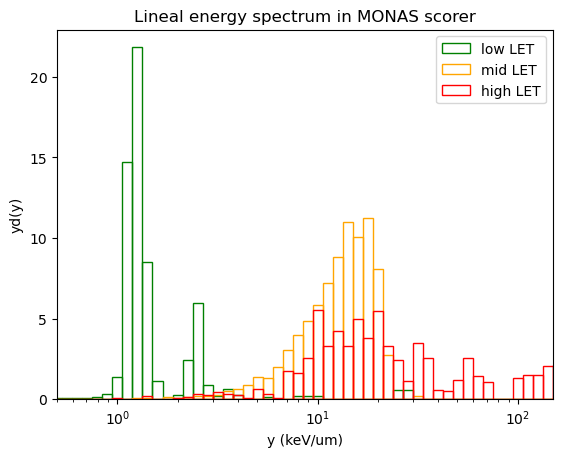

In [10]:
plt.bar(ylow['y'], ylow['y']*ylow['dy'], label='low LET', width=generate_binwidths(ylow['y']), align='edge', fill=False, edgecolor='green')
plt.bar(ymid['y'], ymid['y']*ymid['dy'], label='mid LET', width=generate_binwidths(ymid['y']), align='edge', fill=False, edgecolor='orange')
plt.bar(yhigh['y'], yhigh['y']*yhigh['dy'], label='high LET', width=generate_binwidths(yhigh['y']), align='edge', fill=False, edgecolor='red')
plt.xscale('log')
plt.xlim([0.5,150])
plt.xlabel('y (keV/um)')
plt.ylabel('yd(y)')
plt.title('Lineal energy spectrum in MONAS scorer')
plt.legend()

In [11]:
letlow, stdlow = Y_to_LET(ylow)

letmid, stdmid = Y_to_LET(ymid)

lethigh, stdhigh = Y_to_LET(yhigh)


Mean: 1.3 keV/um
Standard Dev: 0.89
Mean: 10.11 keV/um
Standard Dev: 4.98
Mean: 16.49 keV/um
Standard Dev: 33.93


# Calculating survival and RBE from y spectra

In [12]:
def spectrum_calc(spectrumfile):

    #constants
    y0 = 150
    Rd = 0.44
    rho = 1
    #cell survival constants taken from Rørvik fit                     
    a0 = 0.317
    b = 0.057
    aR = 0.242


    #parameters from yspecfile
    y = spectrumfile['y']
    dy = spectrumfile['dy']
    dy = dy/np.sum(dy)
    ydy = y*dy

    #calculate ystar
    ystar_nominator = np.square(y0)*np.sum((1-np.exp(-(np.square(y))/np.square(y0)))*dy)
    ystar_denominator = np.sum(ydy)
    ystar = ystar_nominator/ystar_denominator

    #calculate survival and RBE data per dose
    data = pd.DataFrame(columns=['Dose', 'S', 'RBE'])
    doses = np.arange(0, 8.5, 0.1)
    for d in doses:
        newrow = {}
        newrow['Dose'] = d

        #calculate survival
        exponent = -(a0 + ((b)/(rho*math.pi*np.square(Rd)))*ystar*0.16)*d - b*np.square(d)
        newrow['S'] = np.exp(exponent)

        #calculate RBE
        RBE_nominator = np.sqrt(np.square(aR) - 4*b*np.log(newrow['S'])) - aR
        RBE_denominator = 2*b*d
        newrow['RBE'] = RBE_nominator/RBE_denominator

        data = pd.concat([data, pd.DataFrame([newrow])])


    return data

In [13]:
low = spectrum_calc(ylow)

mid = spectrum_calc(ymid)

high = spectrum_calc(yhigh)

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA colum

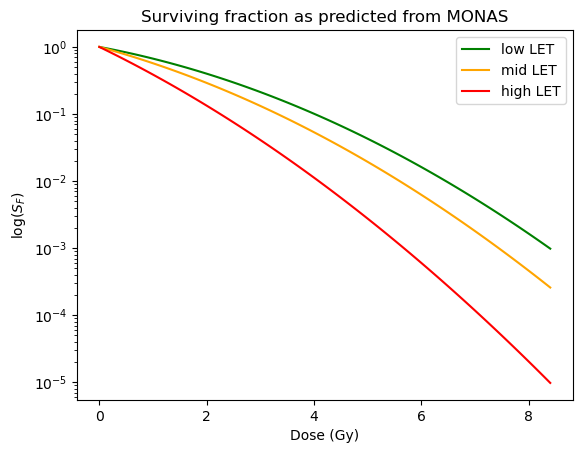

In [14]:
plt.plot(low['Dose'], low['S'], label='low LET', color='green')
plt.plot(mid['Dose'], mid['S'], label='mid LET', color ='orange')
plt.plot(high['Dose'], high['S'], label='high LET', color ='red')
plt.yscale('log')
plt.title('Surviving fraction as predicted from MONAS')
plt.xlabel('Dose (Gy)')
plt.ylabel('log($S_F$)')
plt.legend()

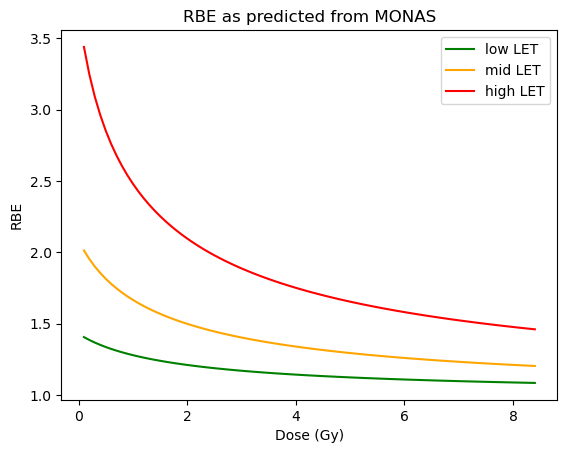

In [15]:
plt.plot(low['Dose'], low['RBE'], label='low LET', color='green')
plt.plot(mid['Dose'], mid['RBE'], label='mid LET', color='orange')
plt.plot(high['Dose'], high['RBE'], label='high LET', color ='red')
plt.title('RBE as predicted from MONAS')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.legend()

# A Gaussian y approximation model

<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\2107639257.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('Mean LET in y (keV/$\mu$m)')


Text(0, 1, 'y=1.07$^x$')

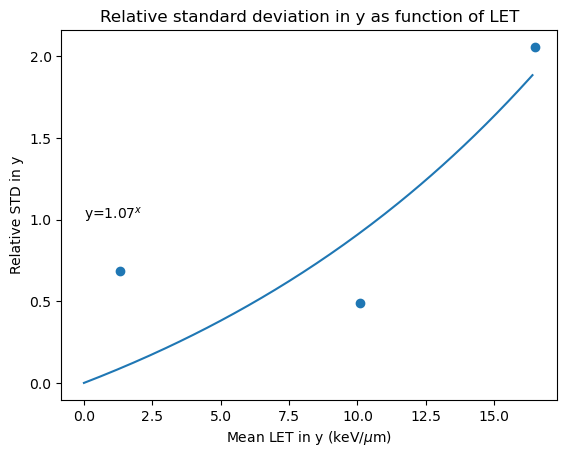

In [16]:
#First, figure out the relationship between mean and spread
lets = [letlow, letmid, lethigh]
stds = [stdlow, stdmid, stdhigh]

#Or...standardised std
standardised = []
for i in range(len(lets)):
    standardised.append(stds[i]/lets[i])

def exponential_func(x, b):
    return np.power(b, x) - 1


exponential_param, pcov = curve_fit(exponential_func, lets, standardised, (0.5))

plt.plot(np.arange(0, lethigh, 0.1), exponential_func(np.arange(0, lethigh, 0.1), exponential_param[0]))
plt.scatter(lets, standardised)
plt.title('Relative standard deviation in y as function of LET')
plt.xlabel('Mean LET in y (keV/$\mu$m)')
plt.ylabel('Relative STD in y')
plt.text(0, 1, f'y={round(exponential_param[0],2)}$^x$')

In [17]:
def bin_edges(input):
    
    try:
        centrevalues = input.to_numpy()
    except AttributeError:
        centrevalues = input

    widths = generate_binwidths(centrevalues)
    
    edges = centrevalues - 0.5*widths

    np.append(edges, centrevalues[-1] + 0.5*widths[-1])

    return edges

In [18]:
def Generate_Gaussian_y(LET, binedges, param, plot):
    #Take LET to calculate std and a Gaussian spectrum
    #Return Gaussian lineal energy spectrum

    def exponential_func(x):
        return np.power(param, x) - 1
    
    #For a given LET, generate a Gaussian spectrum
    relative_std = exponential_func(LET)
    samples = np.random.normal(LET, LET*relative_std, 1000)

    # Create the histogram
    dy, bins, patches = plt.hist(samples, bins=np.sort(binedges))
    plt.close()

    y = (bins[:-1] + bins[1:])/2
    y = y[np.where(y>0)]
    dy = dy[np.where(y>0)]/y

    if plot == True:
        plt.bar(y, y*dy, width=generate_binwidths(y), align='edge', fill=False)
        plt.xlim([0.5,150])
        plt.title(f'Gaussian y spectrum, {LET} keV/$\mu$m')
        plt.xlabel('y (keV/$\mu$m)')
        plt.ylabel('yd(y)')
        plt.xscale('log')
        plt.show()

    return pd.DataFrame({'y': y, 'dy': dy})

<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
<>:23: SyntaxWarning: invalid escape sequence '\m'
<>:24: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3202087894.py:23: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Gaussian y spectrum, {LET} keV/$\mu$m')
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3202087894.py:24: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('y (keV/$\mu$m)')


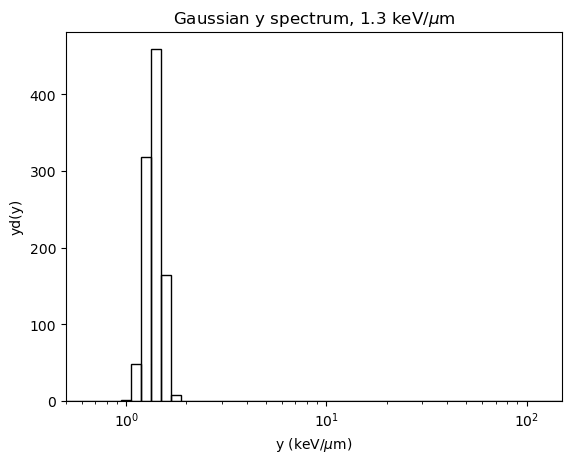

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


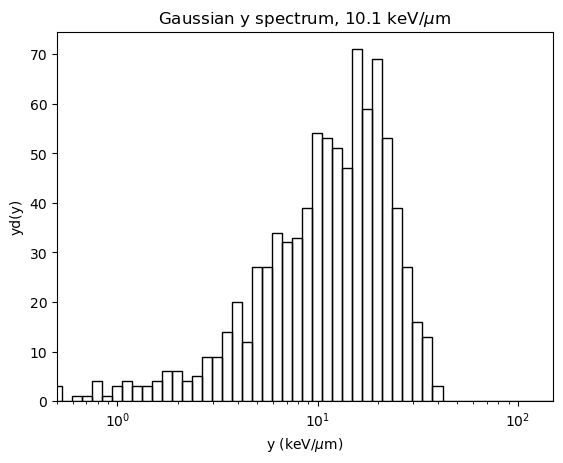

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


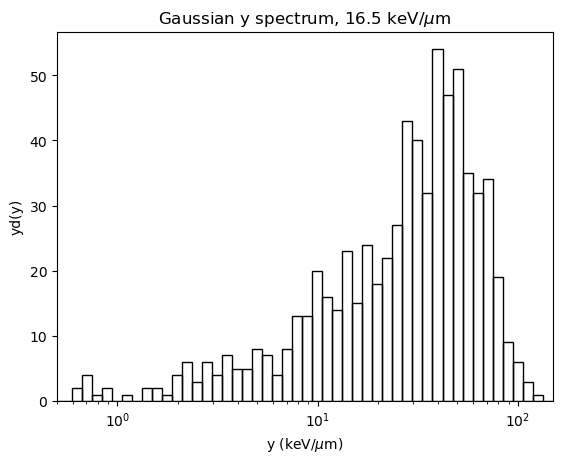

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


In [19]:
lowphen = spectrum_calc(Generate_Gaussian_y(1.3, bin_edges(ylow['y']), exponential_param[0], True))

midphen = spectrum_calc(Generate_Gaussian_y(10.1, bin_edges(ylow['y']), exponential_param[0], True))

highphen = spectrum_calc(Generate_Gaussian_y(16.5, bin_edges(ylow['y']), exponential_param[0], True))

# A delta y approximation

In [20]:
from sympy import DiracDelta

In [21]:
def Generate_Delta_y(LET, binedges, plot):
    #Take LET to calculate a delta y spectrum
    #Return delta lineal energy spectrum
    samples = LET

    # Create the histogram
    dy, bins, patches = plt.hist(samples, bins=np.sort(binedges))
    plt.close()

    y = (bins[:-1] + bins[1:])/2
    y = y[np.where(y>0)]
    dy = dy[np.where(y>0)]/y

    if plot == True:
        plt.bar(y, y*dy, width=generate_binwidths(y), align='edge', fill=False)
        plt.xlim([0.5,150])
        plt.title(f'Gaussian y spectrum, {LET} keV/$\mu$m')
        plt.xlabel('y (keV/$\mu$m)')
        plt.ylabel('yd(y)')
        plt.xscale('log')
        plt.show()

    return pd.DataFrame({'y': y, 'dy': dy})

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:18: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\1409476324.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Gaussian y spectrum, {LET} keV/$\mu$m')
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\1409476324.py:18: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('y (keV/$\mu$m)')


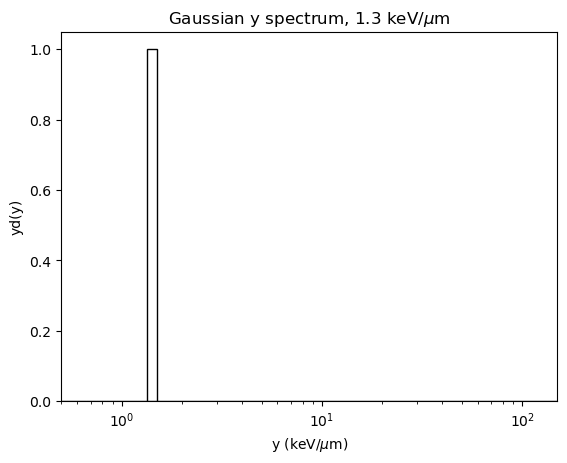

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


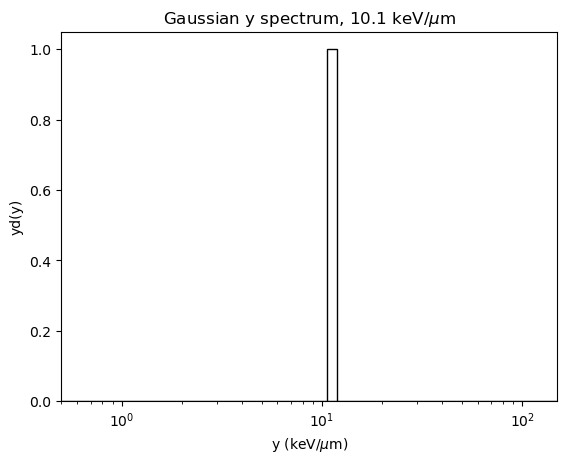

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


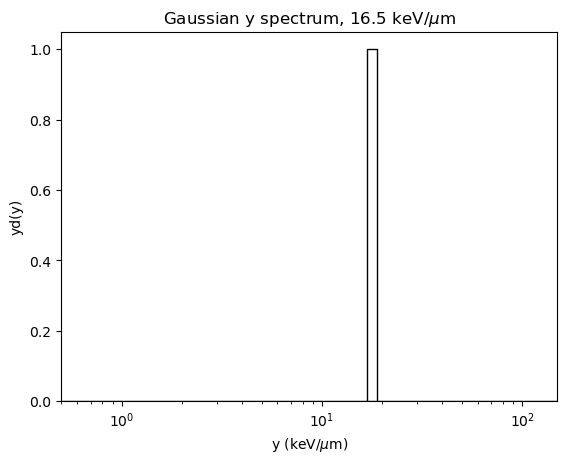

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


In [22]:
lowd = spectrum_calc(Generate_Delta_y(1.3, bin_edges(ylow['y']), True))

midd = spectrum_calc(Generate_Delta_y(10.1, bin_edges(ylow['y']), True))

highd = spectrum_calc(Generate_Delta_y(16.5, bin_edges(ylow['y']), True))

# A joint Delta-Landau fit

In [23]:
from landaupy import landau

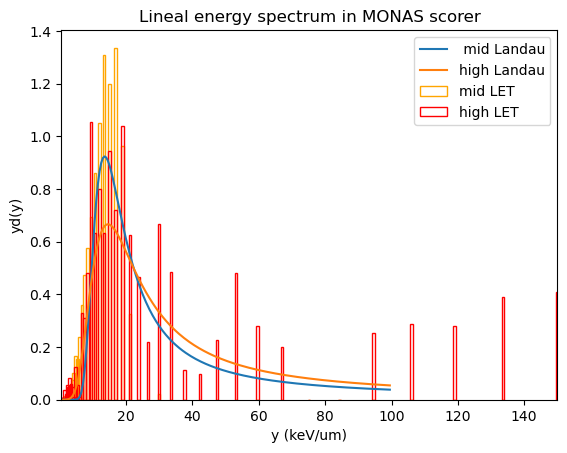

In [24]:
#Fine tuning the landau distribution parameters (By the eye, very scientific)
plt.bar(ymid['y'], ymid['y']*(ymid['dy']/np.sum(ymid['dy'])), label='mid LET', fill=False, edgecolor='orange')
y = np.arange(0, 100, 0.5)
dy = landau.pdf(x=y, x_mpv=1.2*10.1, xi=2.5)
plt.plot(y, y*dy, label=' mid Landau')

plt.bar(yhigh['y'], yhigh['y']*(yhigh['dy']/np.sum(yhigh['dy'])), label='high LET', fill=False, edgecolor='red')
y = np.arange(0, 100, 0.5)
dy = landau.pdf(x=y, x_mpv=0.7*16.5, xi=3.5)
plt.plot(y, y*dy, label='high Landau')

plt.xlim([0.5,150])
plt.xlabel('y (keV/um)')
plt.ylabel('yd(y)')
plt.title('Lineal energy spectrum in MONAS scorer')
plt.legend()

In [25]:
def Generate_combined_y(LET, binedges, plot):
    #Take LET to calculate a delta y spectrum
    #Return delta lineal energy spectrum
    if LET < 10:
        samples = LET

        # Create the histogram
        dy, bins, patches = plt.hist(samples, bins=np.sort(binedges))
        plt.close()

        y = (bins[:-1] + bins[1:])/2
        y = y[np.where(y>0)]
        dy = dy[np.where(y>0)]/y

    else:
        #find mpv and xi from my very scientific curve tuning and linear curve fit
        xi = (2/13)*LET + 0.96
        mpv_factor = -(1/13)*LET + 1.97
        y = np.arange(0, 100, 0.5)
        dy = landau.pdf(x=y, x_mpv=mpv_factor*LET, xi=xi)

    if plot == True:
        plt.bar(y, y*dy, align='edge', fill=False)
        plt.xlim([0.5,150])
        plt.title(f'Gaussian y spectrum, {LET} keV/$\mu$m')
        plt.xlabel('y (keV/$\mu$m)')
        plt.ylabel('yd(y)')
        plt.show()

    return pd.DataFrame({'y': y, 'dy': dy})

<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
<>:25: SyntaxWarning: invalid escape sequence '\m'
<>:26: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\1988300899.py:25: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Gaussian y spectrum, {LET} keV/$\mu$m')
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\1988300899.py:26: SyntaxWarning: invalid escape sequence '\m'
  plt.xlabel('y (keV/$\mu$m)')


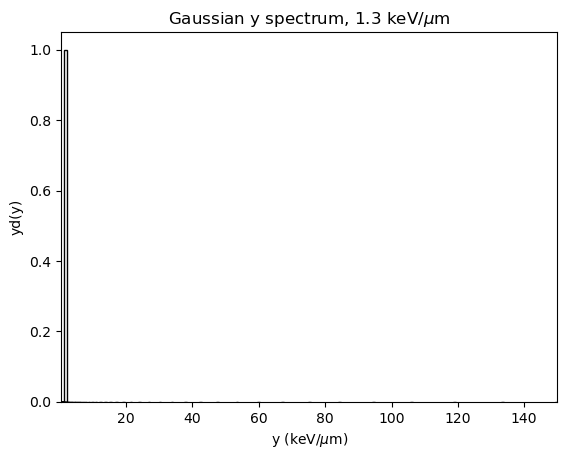

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


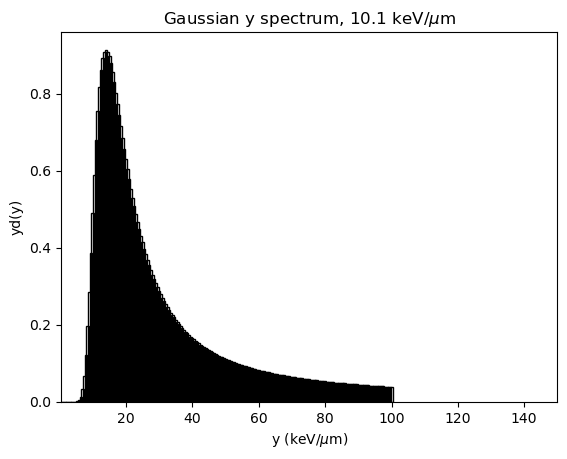

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


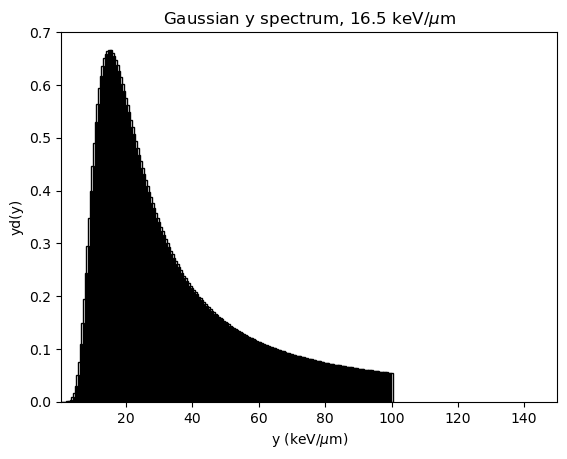

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


In [26]:
lowc = spectrum_calc(Generate_combined_y(1.3, bin_edges(ylow['y']), True))

midc = spectrum_calc(Generate_combined_y(10.1, bin_edges(ylow['y']), True))

highc = spectrum_calc(Generate_combined_y(16.5, bin_edges(ylow['y']), True))

# Comparing TOPAS/Rørvik/y approximation predictions

In [27]:
def R_Func(X, a, b, c):
    d, l, dtwo = X
    return np.exp(-(a*d + b*l + c*dtwo))

In [28]:
def Calculate_RBE(d, let, p):

    if d == 0:
        RBE = float('nan')

    else:
        a_x = p[0]
        b_x = p[2]
        k = p[1]

        RBEmin = 1
        RBEmax = 1 + (k/a_x)*let
        A_B = a_x/b_x

        squareterm = np.square(A_B) + 4*d*A_B*RBEmax + 4*np.square(d)*np.square(RBEmin)
        RBE = (1/(2*d))*(np.sqrt(squareterm) - A_B)

    return RBE

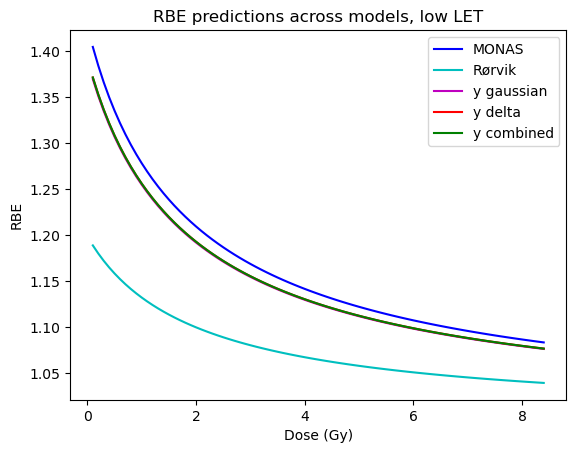

In [29]:
d = np.arange(0, 8.5, 0.1)
x = (d, d*1.3, np.square(d))
RBE_rorvik = np.zeros(len(d))
for i in range(len(d)):
    RBE_rorvik[i] = Calculate_RBE(d[i], 1.3, [0.242, 0.037, 0.057])

plt.plot(low['Dose'], low['RBE'], label = 'MONAS', color = 'b')
plt.plot(d, RBE_rorvik, label = 'Rørvik', color = 'c')
plt.plot(lowphen['Dose'], lowphen['RBE'], label = 'y gaussian', color = 'm')
plt.plot(lowd['Dose'], lowd['RBE'], label = 'y delta', color = 'r')
plt.plot(lowc['Dose'], lowc['RBE'], label = 'y combined', color = 'g')
plt.title('RBE predictions across models, low LET')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.legend()

Text(90, 1.42, 'RBE90')

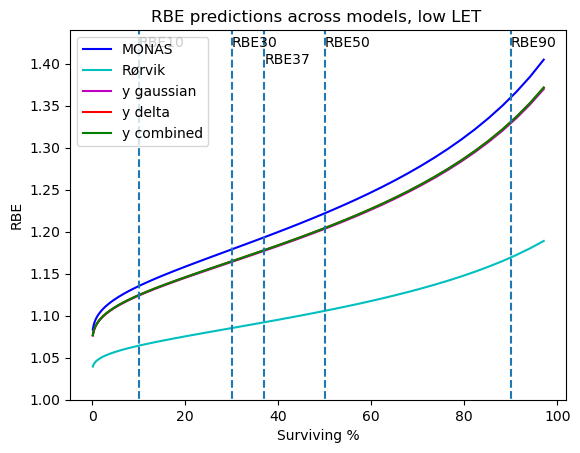

In [30]:
S_percentages = 100*R_Func(x, 0.242, 0.037, 0.057)

plt.plot(S_percentages, low['RBE'], label = 'MONAS', color = 'b')
plt.plot(S_percentages, RBE_rorvik, label = 'Rørvik', color = 'c')
plt.plot(S_percentages, lowphen['RBE'], label = 'y gaussian', color = 'm')
plt.plot(S_percentages, lowd['RBE'], label = 'y delta', color = 'r')
plt.plot(S_percentages, lowc['RBE'], label = 'y combined', color = 'g')
plt.title('RBE predictions across models, low LET ')
plt.xlabel('Surviving %')
plt.ylabel('RBE')
plt.legend()
plt.ylim([1, 1.44])
plt.vlines(10, 0, 5, linestyles='--')
plt.text(10, 1.42, 'RBE10')
plt.vlines(30, 0, 5, linestyles='--')
plt.text(30, 1.42, 'RBE30')
plt.vlines(37, 0, 5, linestyles='--')
plt.text(37, 1.40, 'RBE37')
plt.vlines(50, 0, 5, linestyles='--')
plt.text(50, 1.42, 'RBE50')
plt.vlines(90, 0, 5, linestyles='--')
plt.text(90, 1.42, 'RBE90')

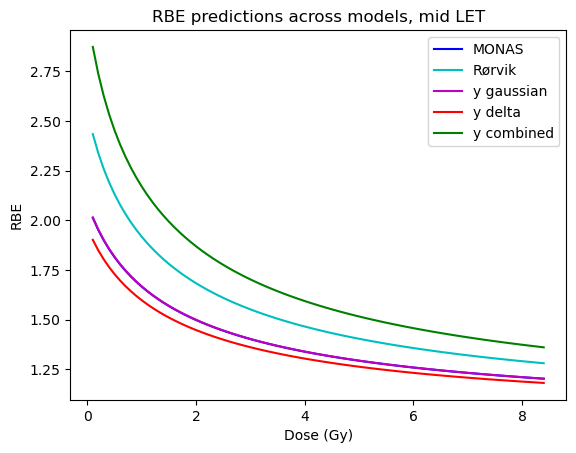

In [31]:
d = np.arange(0, 8.5, 0.1)
x = (d, d*10.1, np.square(d))
RBE_rorvik = np.zeros(len(d))
for i in range(len(d)):
    RBE_rorvik[i] = Calculate_RBE(d[i], 10.1, [0.241, 0.037, 0.057])

plt.plot(mid['Dose'], mid['RBE'], label = 'MONAS', color = 'b')
plt.plot(d, RBE_rorvik, label = 'Rørvik', color = 'c')
plt.plot(midphen['Dose'], midphen['RBE'], label = 'y gaussian', color = 'm')
plt.plot(midd['Dose'], midd['RBE'], label = 'y delta', color = 'r')
plt.plot(midc['Dose'], midc['RBE'], label = 'y combined', color = 'g')
plt.title('RBE predictions across models, mid LET')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.legend()

Text(90, 2.42, 'RBE90')

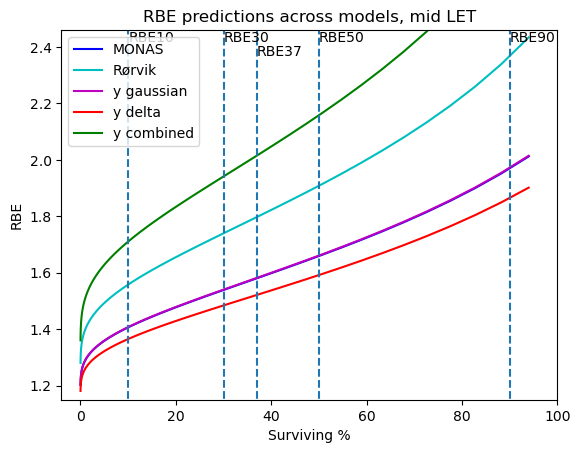

In [32]:
S_percentages = 100*R_Func(x, 0.242, 0.037, 0.057)

plt.plot(S_percentages, mid['RBE'], label = 'MONAS', color = 'b')
plt.plot(S_percentages, RBE_rorvik, label = 'Rørvik', color = 'c')
plt.plot(S_percentages, midphen['RBE'], label = 'y gaussian', color = 'm')
plt.plot(S_percentages, midd['RBE'], label = 'y delta', color = 'r')
plt.plot(S_percentages, midc['RBE'], label = 'y combined', color = 'g')
plt.title('RBE predictions across models, mid LET')
plt.xlabel('Surviving %')
plt.ylabel('RBE')
plt.legend()
plt.ylim([1.15, 2.46])
plt.xlim([-4, 100])
plt.vlines(10, 0, 5, linestyles='--')
plt.text(10, 2.42, 'RBE10')
plt.vlines(30, 0, 5, linestyles='--')
plt.text(30, 2.42, 'RBE30')
plt.vlines(37, 0, 5, linestyles='--')
plt.text(37, 2.37, 'RBE37')
plt.vlines(50, 0, 5, linestyles='--')
plt.text(50, 2.42, 'RBE50')
plt.vlines(90, 0, 5, linestyles='--')
plt.text(90, 2.42, 'RBE90')

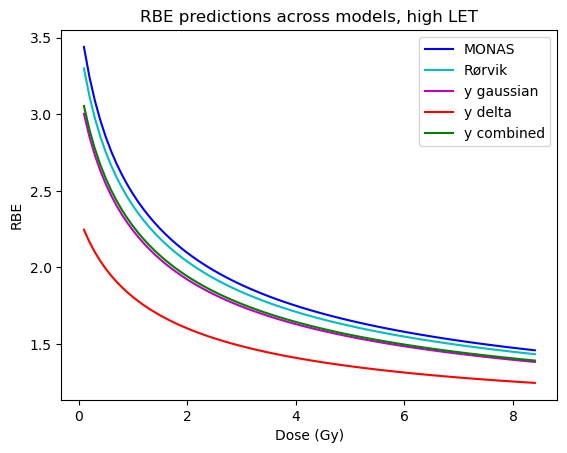

In [33]:
plt.plot(high['Dose'], high['RBE'], label = 'MONAS', color = 'b')

d = np.arange(0, 8.5, 0.1)
x = (d, d*16.5, np.square(d))
RBE_rorvik = np.zeros(len(d))
for i in range(len(d)):
    RBE_rorvik[i] = Calculate_RBE(d[i], 16.5, [0.241, 0.037, 0.057])

plt.plot(d, RBE_rorvik, label = 'Rørvik', color = 'c')
plt.plot(highphen['Dose'], highphen['RBE'], label = 'y gaussian', color = 'm')
plt.plot(highd['Dose'], highd['RBE'], label = 'y delta', color = 'r')
plt.plot(highc['Dose'], highc['RBE'], label = 'y combined', color = 'g')
plt.title('RBE predictions across models, high LET')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.legend()

Text(90, 3.5, 'RBE90')

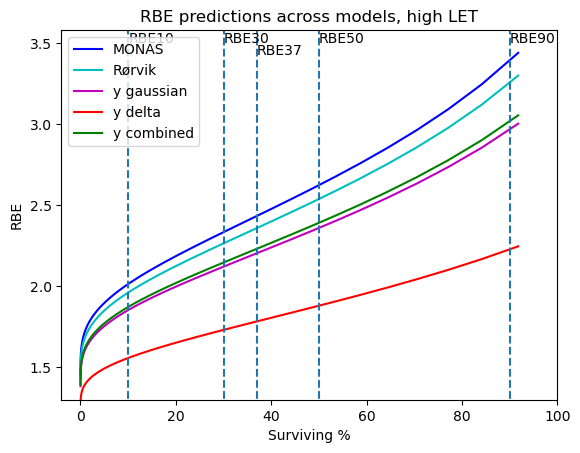

In [34]:
S_percentages = 100*R_Func(x, 0.242, 0.037, 0.057)

plt.plot(S_percentages, high['RBE'], label = 'MONAS', color = 'b')
plt.plot(S_percentages, RBE_rorvik, label = 'Rørvik', color = 'c')
plt.plot(S_percentages, highphen['RBE'], label = 'y gaussian', color = 'm')
plt.plot(S_percentages, highd['RBE'], label = 'y delta', color = 'r')
plt.plot(S_percentages, highc['RBE'], label = 'y combined', color = 'g')
plt.title('RBE predictions across models, high LET')
plt.xlabel('Surviving %')
plt.ylabel('RBE')
plt.legend()
plt.ylim([1.30, 3.58])
plt.xlim([-4, 100])
plt.vlines(10, 0, 5, linestyles='--')
plt.text(10, 3.50, 'RBE10')
plt.vlines(30, 0, 5, linestyles='--')
plt.text(30, 3.50, 'RBE30')
plt.vlines(37, 0, 5, linestyles='--')
plt.text(37, 3.43, 'RBE37')
plt.vlines(50, 0, 5, linestyles='--')
plt.text(50, 3.50, 'RBE50')
plt.vlines(90, 0, 5, linestyles='--')
plt.text(90, 3.50, 'RBE90')

# RMS bar plots for all

In [47]:
def Calculate_RMS(truthpath, monasdata, phen, delta, comb, letval):
    
    truth = pd.read_excel(truthpath)

    #Rorvik prediction
    if letval < 15:
        d = np.array([0, 2, 5, 8])
        samples = 4
    else:
        d = np.array([0, 2, 5])
        samples = 3
    x = (d, d*letval, np.square(d))
    S_rorvik = R_Func(x, 0.241, 0.037, 0.057)
    pred_rorvik = np.tile(np.array(S_rorvik), int(len(truth)/samples))

    #Monas prediction
    S_monas = monasdata[monasdata['Dose'].isin(d)]
    S_monas = S_monas['S']
    pred_monas = np.tile(np.array(S_monas), int(len(truth)/samples))

    #Phen prediction
    S_phen = phen[phen['Dose'].isin(d)]
    S_phen = S_phen['S']
    pred_phen = np.tile(np.array(S_phen), int(len(truth)/samples))

    #Delta prediction
    S_delta = delta[delta['Dose'].isin(d)]
    S_delta = S_delta['S']
    pred_delta = np.tile(np.array(S_delta), int(len(truth)/samples))

    #Combo prediction
    S_comb = comb[comb['Dose'].isin(d)]
    S_comb = S_comb['S']
    pred_comb = np.tile(np.array(S_comb), int(len(truth)/samples))

    #calculate rms
    rmsrorvik = root_mean_squared_error(truth['Mean Survival'], pred_rorvik)
    rmsmonas = root_mean_squared_error(truth['Mean Survival'], pred_monas)
    rmsphen = root_mean_squared_error(truth['Mean Survival'], pred_phen)
    rmsdelta = root_mean_squared_error(truth['Mean Survival'], pred_delta)
    rmscomb = root_mean_squared_error(truth['Mean Survival'], pred_comb)

    #Plot together
    plt.plot(monasdata['Dose'], monasdata['S'], label='MONAS', color = 'b')
    d = np.arange(0, 8.6, 0.1)
    plt.plot(d, R_Func((d, d*letval, np.square(d)), 0.241, 0.037, 0.057), label = 'Rørvik', color = 'c')
    plt.plot(phen['Dose'], phen['S'], label='y gaussian', color = 'm')
    plt.plot(delta['Dose'], delta['S'], label='y delta', color = 'r')
    plt.plot(comb['Dose'], comb['S'], label='y combined', color = 'g')
    if letval == 16.5:
        dose_err = 0.038*truth['Dose']
    else:
        dose_err = 0.029*truth['Dose']
    plt.errorbar(truth['Dose'], truth['Mean Survival'], xerr=dose_err, yerr=truth['STD'], label='Experimental values', fmt='+', capsize=3,)
    plt.yscale('log')
    plt.title(f'Model predictions against real data, protons {letval} keV/$\mu$m')
    plt.xlabel('Dose (Gy)')
    plt.ylabel('$S_F$')
    plt.legend()

    return rmsrorvik, rmsmonas, rmsphen, rmsdelta, rmscomb


<>:56: SyntaxWarning: invalid escape sequence '\m'
<>:56: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3056972309.py:56: SyntaxWarning: invalid escape sequence '\m'
  plt.title(f'Model predictions against real data, protons {letval} keV/$\mu$m')


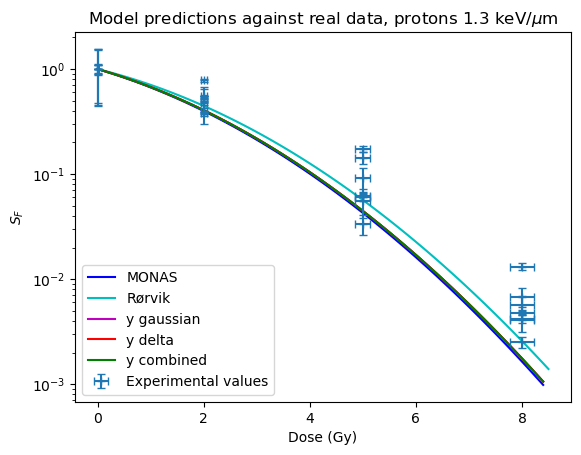

In [48]:
rmsrorvik_total = []
rmsmonas_total = []
rmsphen_total = []
rmsdelta_total = []
rmscomb_total = []

rmsror, rmsmonas, rmsphen, rmsdelta, rmscomb = Calculate_RMS('../Cell survival results/PL_means.xlsx', low, lowphen, lowd, lowc, 1.3)

rmsrorvik_total.append(rmsror)
rmsmonas_total.append(rmsmonas)
rmsphen_total.append(rmsphen)
rmsdelta_total.append(rmsdelta)
rmscomb_total.append(rmscomb)

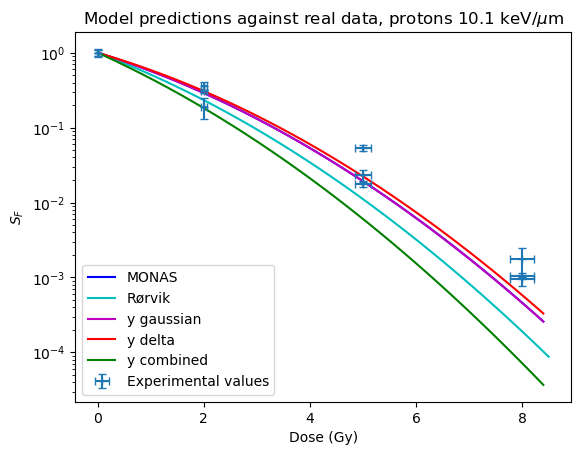

In [49]:
rmsror, rmsmonas, rmsphen, rmsdelta, rmscomb = Calculate_RMS('../Cell survival results/PM_means.xlsx', mid, midphen,midd,midc, 10.1)

rmsrorvik_total.append(rmsror)
rmsmonas_total.append(rmsmonas)
rmsphen_total.append(rmsphen)
rmsdelta_total.append(rmsdelta)
rmscomb_total.append(rmscomb)

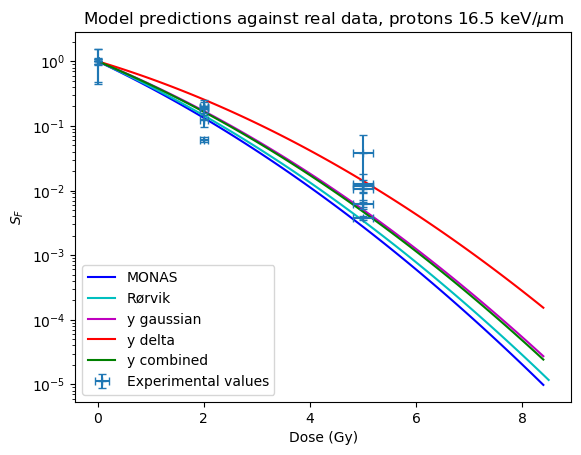

In [50]:
rmsror, rmsmonas, rmsphen, rmsdelta, rmscomb = Calculate_RMS('../Cell survival results/PH_means.xlsx', high, highphen, highd, highc, 16.5)

rmsrorvik_total.append(rmsror)
rmsmonas_total.append(rmsmonas)
rmsphen_total.append(rmsphen)
rmsdelta_total.append(rmsdelta)
rmscomb_total.append(rmscomb)

In [51]:
rmsrorvik_total

[0.07774674388878437, 0.04639117605738999, 0.031762676728042144]

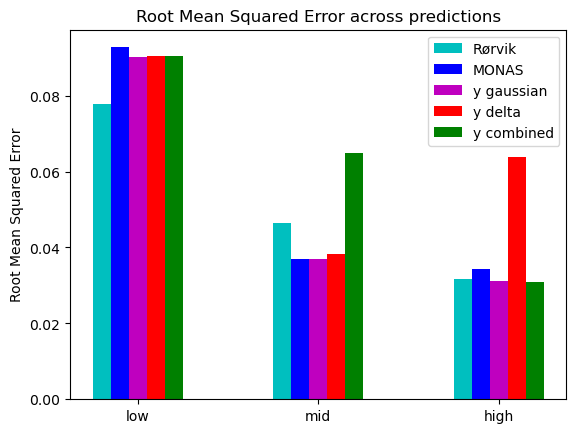

In [52]:
x = np.arange(3)
w = 0.1

fig, ax = plt.subplots()
rects1 = ax.bar(x - 2*w, rmsrorvik_total, w, label = 'Rørvik', color = 'c')
rects2 = ax.bar(x-w, rmsmonas_total, w, label = 'MONAS', color = 'b')
rects3 = ax.bar(x , rmsphen_total, w, label = 'y gaussian', color = 'm')
rects4 = ax.bar(x+w , rmsdelta_total, w, label = 'y delta', color = 'r')
rects3 = ax.bar(x+2*w, rmscomb_total, w, label = 'y combined', color = 'g')

#Customise
ax.set_ylabel('Root Mean Squared Error')
ax.set_xticks(x, ['low', 'mid', 'high'])
ax.legend()
ax.set_title('Root Mean Squared Error across predictions')
plt.show()

# Extra graph

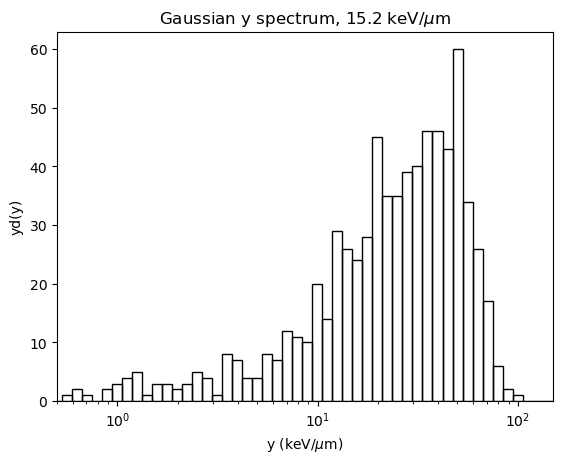

C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:38: RuntimeWarning: invalid value encountered in scalar divide
  newrow['RBE'] = RBE_nominator/RBE_denominator
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\3414937687.py:40: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data = pd.concat([data, pd.DataFrame([newrow])])


In [41]:
newphen = spectrum_calc(Generate_Gaussian_y(15.2, bin_edges(ylow['y']), exponential_param[0], True))

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\1561841939.py:9: SyntaxWarning: invalid escape sequence '\m'
  plt.title('RBE predictions across models, LET=5.5 keV/$\mu$m')


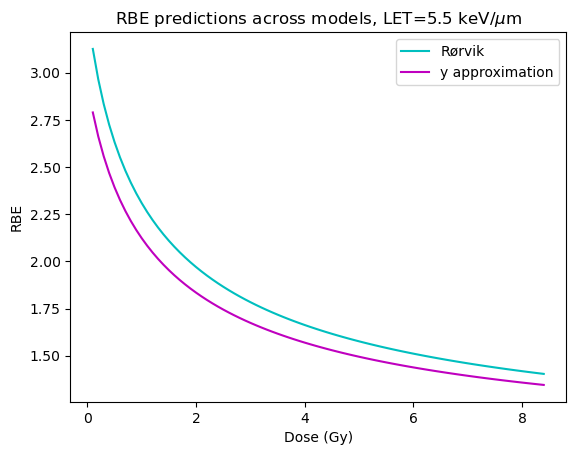

In [42]:
d = np.arange(0, 8.5, 0.1)
x = (d, d*15.2, np.square(d))
RBE_rorvik = np.zeros(len(d))
for i in range(len(d)):
    RBE_rorvik[i] = Calculate_RBE(d[i], 15.2, [0.241, 0.037, 0.057])

plt.plot(d, RBE_rorvik, label = 'Rørvik', color = 'c')
plt.plot(newphen['Dose'], newphen['RBE'], label = 'y approximation', color = 'm')
plt.title('RBE predictions across models, LET=5.5 keV/$\mu$m')
plt.xlabel('Dose (Gy)')
plt.ylabel('RBE')
plt.legend()

<>:5: SyntaxWarning: invalid escape sequence '\m'
<>:5: SyntaxWarning: invalid escape sequence '\m'
C:\Users\bhaan\AppData\Local\Temp\ipykernel_24068\993130792.py:5: SyntaxWarning: invalid escape sequence '\m'
  plt.title('RBE predictions across models, LET=5.5 keV/$\mu$m')


Text(90, 1.96, 'RBE90')

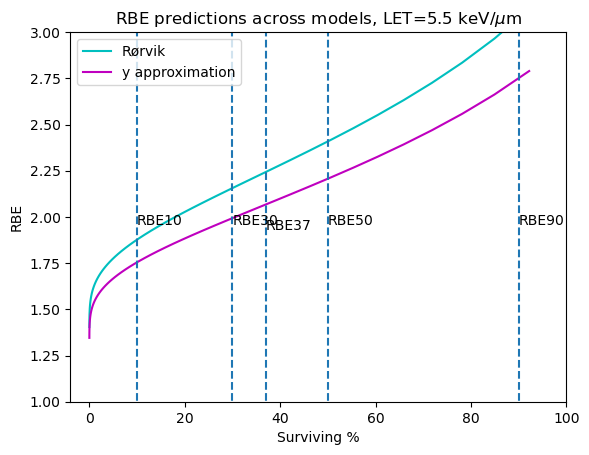

In [43]:
S_percentages = 100*R_Func(x, 0.242, 0.037, 0.057)

plt.plot(S_percentages, RBE_rorvik, label = 'Rørvik', color = 'c')
plt.plot(S_percentages, newphen['RBE'], label = 'y approximation', color = 'm')
plt.title('RBE predictions across models, LET=5.5 keV/$\mu$m')
plt.xlabel('Surviving %')
plt.ylabel('RBE')
plt.legend()
plt.ylim([1, 3.0])
plt.xlim([-4, 100])
plt.vlines(10, 0, 5, linestyles='--')
plt.text(10, 1.96, 'RBE10')
plt.vlines(30, 0, 5, linestyles='--')
plt.text(30, 1.96, 'RBE30')
plt.vlines(37, 0, 5, linestyles='--')
plt.text(37, 1.93, 'RBE37')
plt.vlines(50, 0, 5, linestyles='--')
plt.text(50, 1.96, 'RBE50')
plt.vlines(90, 0, 5, linestyles='--')
plt.text(90, 1.96, 'RBE90')